# Zero-shot reference mapping with scGPT

## Import scGPT and dependencies

In [2]:
from pathlib import Path
import numpy as np
from scipy.stats import mode
import scanpy as sc
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import anndata
from scipy.io import mmread
import seaborn as sns
import pandas as pd
import sys

sys.path.insert(0, "../")

import scgpt as scg

# extra dependency for similarity search
try:
    import faiss

    faiss_imported = True
except ImportError:
    faiss_imported = False
    print(
        "faiss not installed! We highly recommend installing it for fast similarity search."
    )
    print("To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss")

warnings.filterwarnings("ignore", category=ResourceWarning)

/ibex/user/sotoorda/conda-environments/scgpt_env/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/ibex/user/sotoorda/conda-environments/scgpt_env/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


In [3]:
# BUILDING TEST DATA
filename = '/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/xpand_matrix.mtx'
X = mmread(filename)
metadata = pd.read_csv('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/xpand_metadata.csv')
# Opening and formating the gene names
with open('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/xpand_gene_names.csv', 'r') as f:
    genes = f.read().splitlines()

# Building the anndata object
test_adata = anndata.AnnData(X = X.transpose().tocsr())
test_adata.obs = metadata
test_adata.var.index = genes
test_adata.obs.index = test_adata.obs['barcode']

# BUILD REFERENCE DATA
filename = '/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/hca_ref_matrix.mtx'
X = mmread(filename)
metadata = pd.read_csv('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/hca_ref_metadata.csv')
# Opening and formating the gene names
with open('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/hca_ref_gene_names.csv', 'r') as f:
    genes = f.read().splitlines()

# Building the anndata object
adata = anndata.AnnData(X = X.transpose().tocsr())
adata.obs = metadata
adata.var.index = genes
adata.obs.index = adata.obs['barcode']

In [4]:
model_dir = Path("/ibex/user/sotoorda/masterh1/LLM project/scGPT/scGPT_human")

cell_type_key="CellType"
gene_col='index'

Embed the reference dataset

In [5]:
ref_embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

scGPT - INFO - match 14002/14121 genes in vocabulary of size 60697.


/ibex/user/sotoorda/conda-environments/scgpt_env/lib/python3.10/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 1588/1588 [27:00<00:00,  1.02s/it]
/ibex/user/sotoorda/conda-environments/scgpt_env/lib/python3.10/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


Embed the query dataset

In [6]:
test_embed_adata = scg.tasks.embed_data(
    test_adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

scGPT - INFO - match 14051/14170 genes in vocabulary of size 60697.


/ibex/user/sotoorda/conda-environments/scgpt_env/lib/python3.10/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 367/367 [06:15<00:00,  1.02s/it]
/ibex/user/sotoorda/conda-environments/scgpt_env/lib/python3.10/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


Mark the reference vs. query cells and mask the cell types on query cells

In [7]:
# concatenate the two datasets
adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")
# mark the reference vs. query dataset
adata_concat.obs["is_ref"] = ["Query"] * len(test_embed_adata) + ["Reference"] * len(
    ref_embed_adata
)
adata_concat.obs["is_ref"] = adata_concat.obs["is_ref"].astype("category")
# mask the query dataset cell types
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].astype("category")
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].cat.add_categories(["To be predicted"])
adata_concat.obs[cell_type_key][: len(test_embed_adata)] = "To be predicted"

/tmp/ipykernel_1591251/4201321170.py:2: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")
/tmp/ipykernel_1591251/4201321170.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single s

## Visualize the embeddings

We visualize the embeddings from query and reference datasets using UMAP

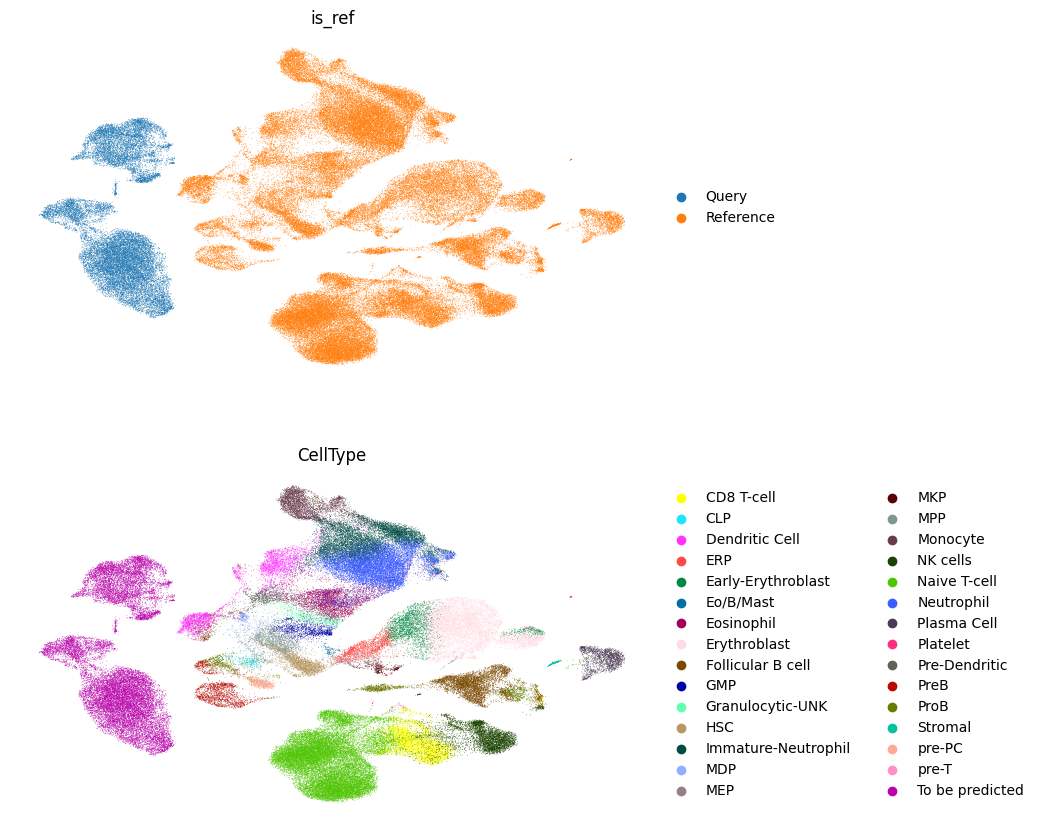

In [8]:
sc.pp.neighbors(adata_concat, use_rep="X_scGPT")
sc.tl.umap(adata_concat)
sc.pl.umap(
    adata_concat, color=["is_ref", cell_type_key], wspace=0.4, frameon=False, ncols=1
)

## Reference mapping and transfer the annotations

In [9]:
# Those functions are only used when faiss is not installed
def l2_sim(a, b):
    sims = -np.linalg.norm(a - b, axis=1)
    return sims

def get_similar_vectors(vector, ref, top_k=10):
        # sims = cos_sim(vector, ref)
        sims = l2_sim(vector, ref)
        
        top_k_idx = np.argsort(sims)[::-1][:top_k]
        return top_k_idx, sims[top_k_idx]

In [10]:
ref_cell_embeddings = ref_embed_adata.obsm["X_scGPT"]
test_emebd = test_embed_adata.obsm["X_scGPT"]

k = 10  # number of neighbors


index = faiss.IndexFlatL2(ref_cell_embeddings.shape[1])
index.add(ref_cell_embeddings)

# Query dataset, k - number of closest elements (returns 2 numpy arrays)
distances, labels = index.search(test_emebd, k)

idx_list=[i for i in range(test_emebd.shape[0])]
preds = []
sim_list = distances
for k in idx_list:
    if faiss_imported:
        idx = labels[k]
    else:
        idx, sim = get_similar_vectors(test_emebd[k][np.newaxis, ...], ref_cell_embeddings, k)
    pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
    preds.append(pred.index[0])
gt = test_adata.obs[cell_type_key].to_numpy()

/tmp/ipykernel_1591251/3100155394.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
/tmp/ipykernel_1591251/3100155394.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
/tmp/ipykernel_1591251/3100155394.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = ref_embed_adata.obs[cell_type_key][idx].valu

In [11]:
# Probability matrix construction
class_names = pd.Index(ref_embed_adata.obs[cell_type_key].astype(str).unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

prob_matrix = np.zeros((test_emebd.shape[0], len(class_names)), dtype=float)

if faiss_imported:
    for i, neighbor_idx in enumerate(labels):
        neighbor_types = ref_embed_adata.obs[cell_type_key].astype(str).to_numpy()[neighbor_idx]
        neighbor_probs = pd.Series(neighbor_types).value_counts(normalize=True)
        for cell_type, prob in neighbor_probs.items():
            prob_matrix[i, class_to_idx[cell_type]] = prob
else:
    for i in idx_list:
        neighbor_idx, _ = get_similar_vectors(
            test_emebd[i][np.newaxis, ...], ref_cell_embeddings, top_k=k
        )
        neighbor_types = ref_embed_adata.obs[cell_type_key].astype(str).to_numpy()[neighbor_idx]
        neighbor_probs = pd.Series(neighbor_types).value_counts(normalize=True)
        for cell_type, prob in neighbor_probs.items():
            prob_matrix[i, class_to_idx[cell_type]] = prob

prob_matrix_df = pd.DataFrame(
    prob_matrix,
    index=test_adata.obs.index,
    columns=class_names,
)

prob_matrix_df.to_csv("/ibex/user/sotoorda/masterh1/LLM project/scGPT/prediction_results.csv", index=True)

In [12]:
# Build benchmark table from probability matrix
bench_df = prob_matrix_df.copy()
bench_df.insert(0, "Cell_id", bench_df.index.astype(str))

# Add labels (aligned by row order/index)
bench_df["Ground_truth"] = pd.Series(gt, index=prob_matrix_df.index).astype(str)
bench_df["scGPT_prediction"] = pd.Series(preds, index=prob_matrix_df.index).astype(str)

# Sanity check: confidence + top1 label derived from probability matrix
prob_cols = prob_matrix_df.columns
bench_df["scGPT_confidence"] = bench_df[prob_cols].max(axis=1)
bench_df["scGPT_top1_from_probs"] = bench_df[prob_cols].idxmax(axis=1)
print("Rows:", len(bench_df), "gt:", len(gt), "preds:", len(preds))
print("Top1 match with preds (%):", (bench_df["scGPT_top1_from_probs"] == bench_df["scGPT_prediction"]).mean() * 100)

# Save
bench_df.to_csv(
    "/ibex/user/sotoorda/masterh1/LLM project/scGPT/scgpt_prob_with_labels.csv",
    index=False
)

Rows: 23466 gt: 23466 preds: 23466
Top1 match with preds (%): 98.35932839001109


In [13]:
bench_df

,Cell_id,NK cells,Naive T-cell,HSC,Dendritic Cell,Pre-Dendritic,ProB,MPP,Neutrophil,Follicular B cell,...,MDP,pre-T,MKP,Stromal,Eo/B/Mast,Platelet,Ground_truth,scGPT_prediction,scGPT_confidence,scGPT_top1_from_probs
barcode,,,,,,,,,,,,,,,,,,,,,
_MO291_AAACAGCCACCACAAC-1,_MO291_AAACAGCCACCACAAC-1,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,ProB,pre-PC,0.9,pre-PC
_MO291_AAACAGCCATCCATCT-1,_MO291_AAACAGCCATCCATCT-1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,HSC,HSC,1.0,HSC
_MO291_AAACATGCACCGTTCC-1,_MO291_AAACATGCACCGTTCC-1,0.0,0.0,0.1,0.0,0.0,0.0,0.7,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,GMP,MPP,0.7,MPP
_MO291_AAACATGCAGCGCTTG-1,_MO291_AAACATGCAGCGCTTG-1,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,ProB,pre-PC,0.9,pre-PC
_MO291_AAACATGCAGGTATTT-1,_MO291_AAACATGCAGGTATTT-1,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,ProB,pre-PC,0.9,pre-PC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
_MO298_TTTGTGAAGGTATTGC-1,_MO298_TTTGTGAAGGTATTGC-1,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,ProB,pre-PC,0.9,pre-PC
_MO298_TTTGTGGCAGGCGAGT-1,_MO298_TTTGTGGCAGGCGAGT-1,0.0,0.0,0.2,0.0,0.0,0.0,0.5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,GMP,MPP,0.5,MPP
_MO298_TTTGTGTTCGCCTGTT-1,_MO298_TTTGTGTTCGCCTGTT-1,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,ProB,pre-PC,0.9,pre-PC


## Evaluate the performance

In [14]:
res_dict = {
    "accuracy": accuracy_score(gt, preds),
    "precision": precision_score(gt, preds, average="macro"),
    "recall": recall_score(gt, preds, average="macro"),
    "macro_f1": f1_score(gt, preds, average="macro"),
}
res_dict

/ibex/user/sotoorda/conda-environments/scgpt_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.20646893377652775,
 'precision': 0.28019873047246635,
 'recall': 0.14577723625452776,
 'macro_f1': 0.15667635134627259}

Confusion matrix:

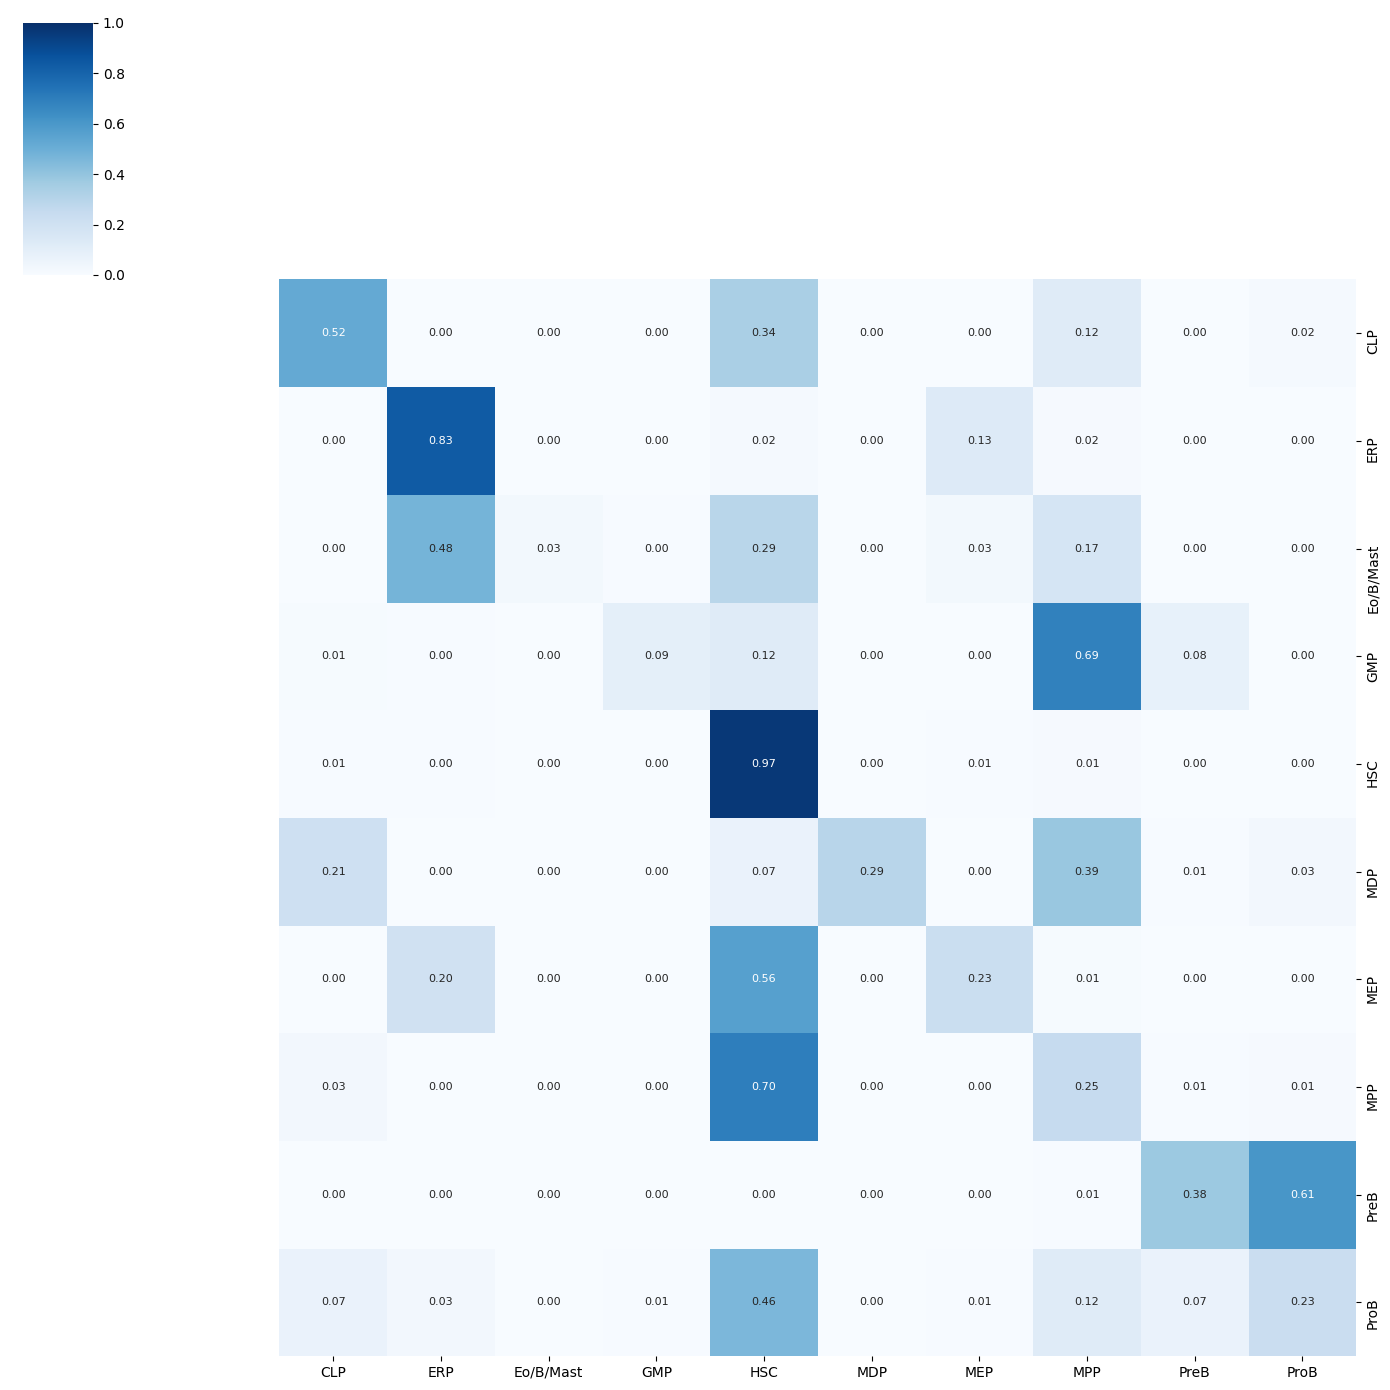

In [15]:
y_true = gt
y_pred = preds
cell_type_list = np.unique(y_true)
matrix = confusion_matrix(y_true, y_pred, labels=cell_type_list)
matrix = matrix.astype("float") / matrix.sum(axis=1)[:, np.newaxis]

df = pd.DataFrame(matrix, index=cell_type_list[:matrix.shape[0]], columns=cell_type_list[:matrix.shape[1]])

ax = sns.clustermap(df,  
                    cmap='Blues',
                    annot=True ,fmt=".2f", 
                    annot_kws={'size': 8}, 
                    vmin=0, 
                    vmax=1,
                    row_cluster=False, 
                    col_cluster=False, 
                    figsize=(14, 14))